(This takes 3–4 minutes)

  Fold 1/10 complete
  Fold 2/10 complete
  Fold 3/10 complete
  Fold 4/10 complete
  Fold 5/10 complete
  Fold 6/10 complete
  Fold 7/10 complete
  Fold 8/10 complete
  Fold 9/10 complete
  Fold 10/10 complete

✓ All predictions collected

McNEMAR'S TEST — PAIRWISE MODEL COMPARISON

Model A                Model B                     χ²    p-value  Significant
---------------------------------------------------------------------------
Logistic Regression    Random Forest          288.390     0.0000        YES ✓
Logistic Regression    XGBoost                281.166     0.0000        YES ✓
Logistic Regression    AdaBoost               222.981     0.0000        YES ✓
Random Forest          XGBoost                  6.000     0.0347        YES ✓
Random Forest          AdaBoost                43.522     0.0000        YES ✓
XGBoost                AdaBoost                31.879     0.0000        YES ✓
Note: p < 0.05 indicates statistically significant difference


PER

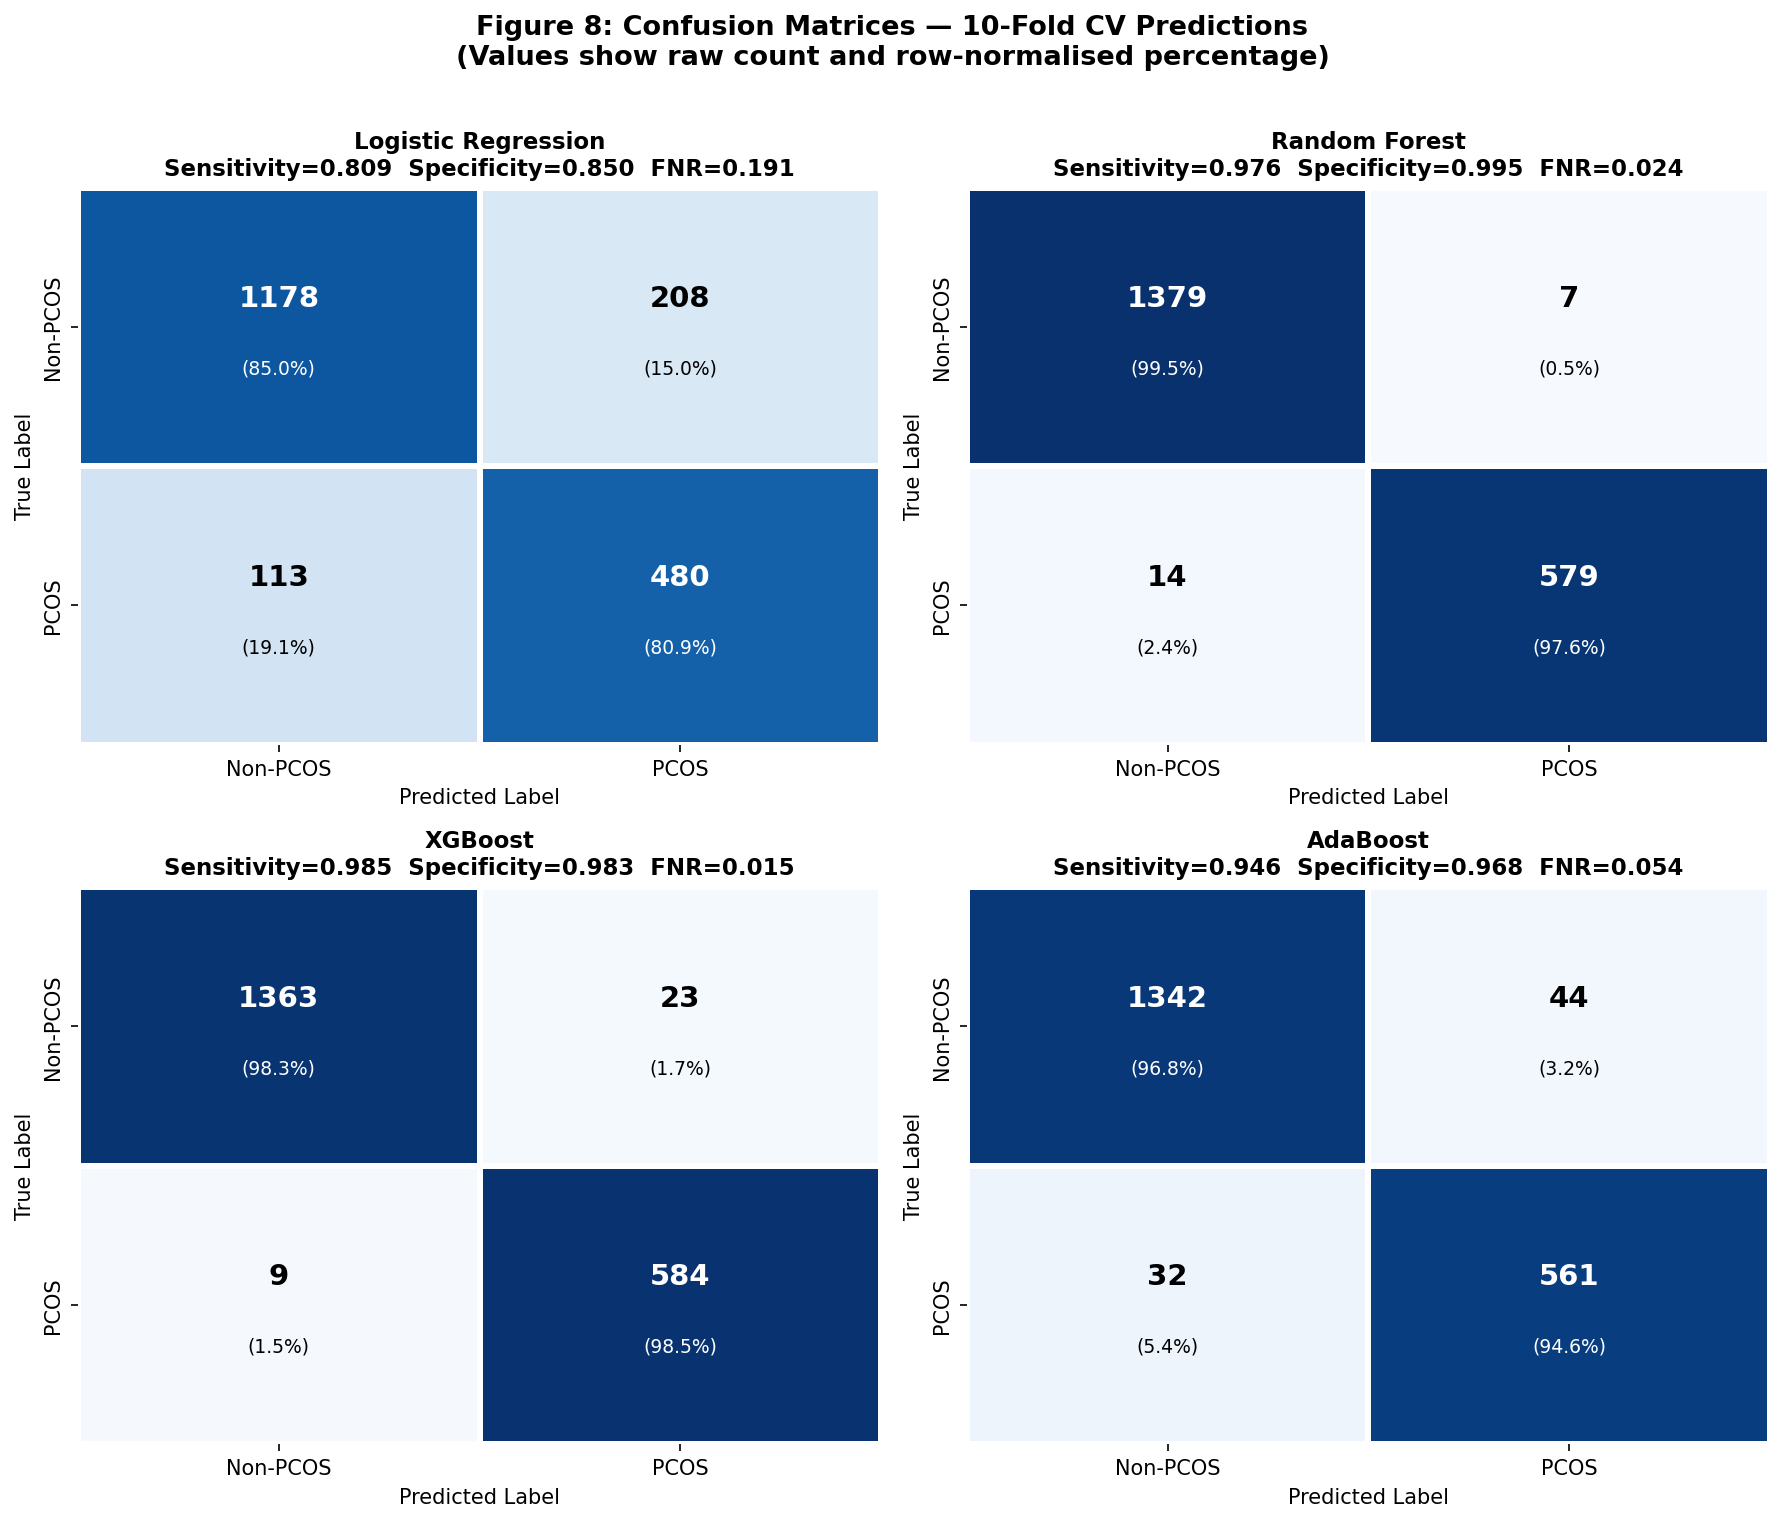


✓ Figure 8 saved


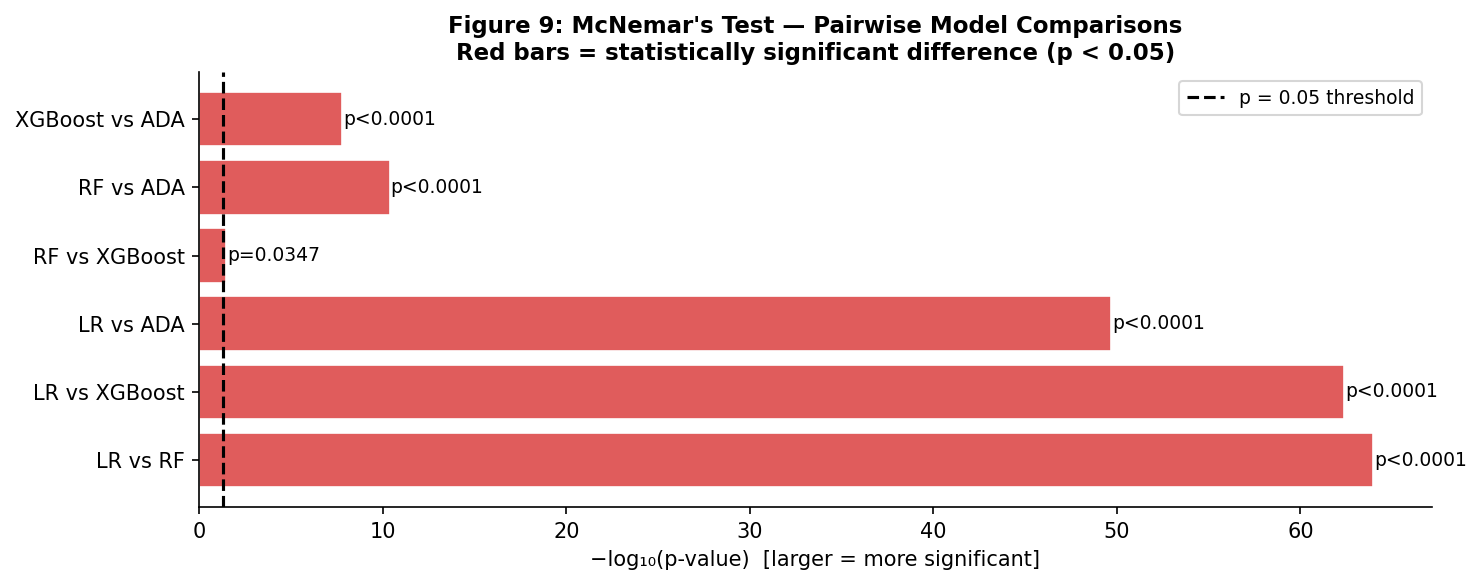

✓ Figure 9 saved

✓ Predictions and test results saved
✓ Ready for Step 6: SHAP Analysis


In [ ]:
# ============================================================
# STEP 5: STATISTICAL SIGNIFICANCE + CONFUSION MATRICES
# PCOS Classification Project
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, ConfusionMatrixDisplay)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from statsmodels.stats.contingency_tables import mcnemar
from scipy import stats

# ── Load data ─────────────────────────────────────────────────
df     = pd.read_csv('PCOS_clean.csv')
target = 'PCOS (Y/N)'
X      = df.drop(columns=[target])
y      = df[target]

def make_pipeline(model):
    return ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=42, k_neighbors=5)),
        ('model',  model)
    ])

# ── Model definitions ─────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000,
        class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, min_samples_split=5,
        min_samples_leaf=2, class_weight='balanced',
        random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y==0).sum()/(y==1).sum(),
        eval_metric='logloss', random_state=42, verbosity=0),
    'AdaBoost': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2),
        n_estimators=200, learning_rate=0.5, random_state=42),
}

# ════════════════════════════════════════════════════════════
# PART 1: COLLECT FOLD-LEVEL PREDICTIONS FOR McNEMAR'S TEST
#
# McNemar's test requires paired predictions — we need to know
# for each patient whether Model A and Model B agreed or
# disagreed. This requires collecting predictions fold by fold.
# ════════════════════════════════════════════════════════════
print("Collecting fold-level predictions for all models...")
print("(This takes 3–4 minutes)\n")

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Store predictions per model: index → predicted label
all_predictions = {name: np.zeros(len(y), dtype=int)
                   for name in models}
all_true        = np.zeros(len(y), dtype=int)

for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    X_train = X.iloc[train_idx]
    X_val   = X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    y_val   = y.iloc[val_idx]

    for name, model in models.items():
        pipe = make_pipeline(model)
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_val)
        all_predictions[name][val_idx] = preds

    all_true[val_idx] = y_val.values
    print(f"  Fold {fold_idx+1}/10 complete")

print("\n✓ All predictions collected\n")

# ════════════════════════════════════════════════════════════
# PART 2: McNEMAR'S TEST
#
# Tests whether two models make significantly different errors.
# H0: both models have the same error rate
# If p < 0.05, the difference is statistically significant.
#
# We test every pair. The most important comparison for your
# paper is RF vs Logistic Regression (best vs baseline).
# ════════════════════════════════════════════════════════════
print("=" * 65)
print("McNEMAR'S TEST — PAIRWISE MODEL COMPARISON")
print("=" * 65)
print(f"\n{'Model A':<22} {'Model B':<22} {'χ²':>7} "
      f"{'p-value':>10} {'Significant':>12}")
print("-" * 75)

model_names = list(models.keys())
mcnemar_results = {}

for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        name_a = model_names[i]
        name_b = model_names[j]

        pred_a = all_predictions[name_a]
        pred_b = all_predictions[name_b]

        # Build contingency table
        # b = A correct, B wrong
        # c = A wrong,   B correct
        correct_a = (pred_a == all_true)
        correct_b = (pred_b == all_true)

        b = np.sum( correct_a & ~correct_b)   # A right, B wrong
        c = np.sum(~correct_a &  correct_b)   # A wrong, B right

        # Use exact test when b+c < 25, chi-squared otherwise
        table  = [[0, b], [c, 0]]
        result = mcnemar(table, exact=(b+c < 25))
        pval   = result.pvalue
        stat   = result.statistic

        sig = "YES ✓" if pval < 0.05 else "no"
        key = f"{name_a} vs {name_b}"
        mcnemar_results[key] = {
            'statistic': stat, 'pvalue': pval,
            'b': b, 'c': c
        }

        print(f"{name_a:<22} {name_b:<22} "
              f"{stat:>7.3f} {pval:>10.4f} {sig:>12}")

print("=" * 65)
print("Note: p < 0.05 indicates statistically significant difference")

# ════════════════════════════════════════════════════════════
# PART 3: PER-CLASS PERFORMANCE BREAKDOWN
# Shows false negative rate — clinically the most important metric
# ════════════════════════════════════════════════════════════
print("\n\n" + "=" * 65)
print("PER-CLASS PERFORMANCE (Clinical Interpretation)")
print("=" * 65)
print(f"\n{'Model':<22} {'Sens(Recall)':>13} "
      f"{'Specificity':>12} {'FNR':>8} {'FPR':>8}")
print("-" * 65)

clinical_metrics = {}
for name in model_names:
    preds = all_predictions[name]
    cm    = confusion_matrix(all_true, preds)
    tn, fp, fn, tp = cm.ravel()

    sensitivity  = tp / (tp + fn)   # recall for PCOS class
    specificity  = tn / (tn + fp)
    fnr          = fn / (fn + tp)   # false negative rate
    fpr          = fp / (fp + tn)   # false positive rate

    clinical_metrics[name] = {
        'sensitivity': sensitivity, 'specificity': specificity,
        'fnr': fnr, 'fpr': fpr,
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn
    }
    print(f"{name:<22} {sensitivity:>13.4f} "
          f"{specificity:>12.4f} {fnr:>8.4f} {fpr:>8.4f}")

print("=" * 65)
print("\nFNR = False Negative Rate (missed PCOS cases — minimise this)")
print("FPR = False Positive Rate (unnecessary follow-up — acceptable)")

# ════════════════════════════════════════════════════════════
# FIGURE 8 — Confusion Matrices (all 4 models)
# ════════════════════════════════════════════════════════════
plt.rcParams.update({
    'font.size': 10, 'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

cm_colors = ['#EAF2FB', '#5B8DB8']  # light blue → strong blue

for idx, name in enumerate(model_names):
    ax    = axes[idx]
    preds = all_predictions[name]
    cm    = confusion_matrix(all_true, preds)
    m     = clinical_metrics[name]

    # Normalised display (proportions) with raw counts annotated
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=False, fmt='.2f',
                cmap='Blues', ax=ax,
                vmin=0, vmax=1,
                linewidths=2, linecolor='white',
                cbar=False,
                xticklabels=['Non-PCOS','PCOS'],
                yticklabels=['Non-PCOS','PCOS'])

    # Annotate with raw count + percentage
    for r in range(2):
        for c in range(2):
            raw  = cm[r, c]
            pct  = cm_norm[r, c] * 100
            color = 'white' if cm_norm[r,c] > 0.6 else 'black'
            ax.text(c + 0.5, r + 0.4,
                    f'{raw}', ha='center', va='center',
                    fontsize=14, fontweight='bold', color=color)
            ax.text(c + 0.5, r + 0.65,
                    f'({pct:.1f}%)', ha='center', va='center',
                    fontsize=9, color=color)

    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_title(
        f'{name}\n'
        f'Sensitivity={m["sensitivity"]:.3f}  '
        f'Specificity={m["specificity"]:.3f}  '
        f'FNR={m["fnr"]:.3f}'
    )

plt.suptitle('Figure 8: Confusion Matrices — 10-Fold CV Predictions\n'
             '(Values show raw count and row-normalised percentage)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig8_confusion_matrices.png')
plt.show()
print("\n✓ Figure 8 saved")

# ════════════════════════════════════════════════════════════
# FIGURE 9 — McNemar's Test Summary (visual)
# ════════════════════════════════════════════════════════════
comparisons = list(mcnemar_results.keys())
pvalues     = [mcnemar_results[k]['pvalue'] for k in comparisons]
short_labels = [k.replace('Logistic Regression', 'LR')
                 .replace('Random Forest', 'RF')
                 .replace('AdaBoost', 'ADA')
                 for k in comparisons]

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['#E05C5C' if p < 0.05 else '#A8C8A0'
              for p in pvalues]
bars = ax.barh(short_labels, [-np.log10(p) for p in pvalues],
               color=bar_colors, edgecolor='white', linewidth=0.8)
ax.axvline(x=-np.log10(0.05), color='black',
           linestyle='--', linewidth=1.5,
           label='p = 0.05 threshold')
ax.set_xlabel('−log₁₀(p-value)  [larger = more significant]')
ax.set_title('Figure 9: McNemar\'s Test — Pairwise Model Comparisons\n'
             'Red bars = statistically significant difference (p < 0.05)')
ax.legend(fontsize=9)

for bar, pval in zip(bars, pvalues):
    label = f'p={pval:.4f}' if pval >= 0.0001 else 'p<0.0001'
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig9_mcnemar_test.png')
plt.show()
print("✓ Figure 9 saved")

# ════════════════════════════════════════════════════════════
# SAVE FOR LATER STEPS
# ════════════════════════════════════════════════════════════
with open('step5_predictions.pkl', 'wb') as f:
    pickle.dump({
        'all_predictions':  all_predictions,
        'all_true':         all_true,
        'mcnemar_results':  mcnemar_results,
        'clinical_metrics': clinical_metrics
    }, f)

print("\n✓ Predictions and test results saved")
print("✓ Ready for Step 6: SHAP Analysis")